# IS 4487 Assignment 14: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


Transportation
- Delta
- United
- FedEx
- Union Pacific Railroad

In [2]:
# Replace this list with your selected tickers
tickers = ['DAL', 'UAL', 'FDX', 'UNP']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [3]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [5]:
# Download adjusted close prices
df = yf.download(tickers, start="2020-01-01", end="2025-01-01")['High']

/tmp/ipykernel_6450/379398263.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2025-01-01")['High']
[*********************100%***********************]  4 of 4 completed


In [6]:
df.head()

Ticker,DAL,FDX,UAL,UNP
Date,,,,
2020-01-02,57.224923,138.243866,90.570000,158.825729
2020-01-03,56.001223,136.675131,88.160004,157.789421
2020-01-06,55.654348,136.862311,88.070000,156.822775
2020-01-07,55.953041,138.350793,88.160004,156.387367
2020-01-08,57.234554,140.605852,88.449997,157.667544


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [7]:
# 1
df.isnull().sum()

,0
Ticker,
DAL,0
FDX,0
UAL,0
UNP,0


In [8]:
# 2
df = df.fillna(method='ffill')

/tmp/ipykernel_6450/2425965120.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [9]:
# 3
df.isnull().sum()

,0
Ticker,
DAL,0
FDX,0
UAL,0
UNP,0


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [10]:
# 1
returns = df.pct_change()

In [11]:
# 2
returns = returns.dropna()

In [12]:
# 3
returns.head()

Ticker,DAL,FDX,UAL,UNP
Date,,,,
2020-01-03,-0.021384,-0.011348,-0.026609,-0.006525
2020-01-06,-0.006194,0.001370,-0.001021,-0.006126
2020-01-07,0.005367,0.010876,0.001022,-0.002776
2020-01-08,0.022903,0.016300,0.003289,0.008186
2020-01-09,0.001179,0.003550,0.003053,-0.001215


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




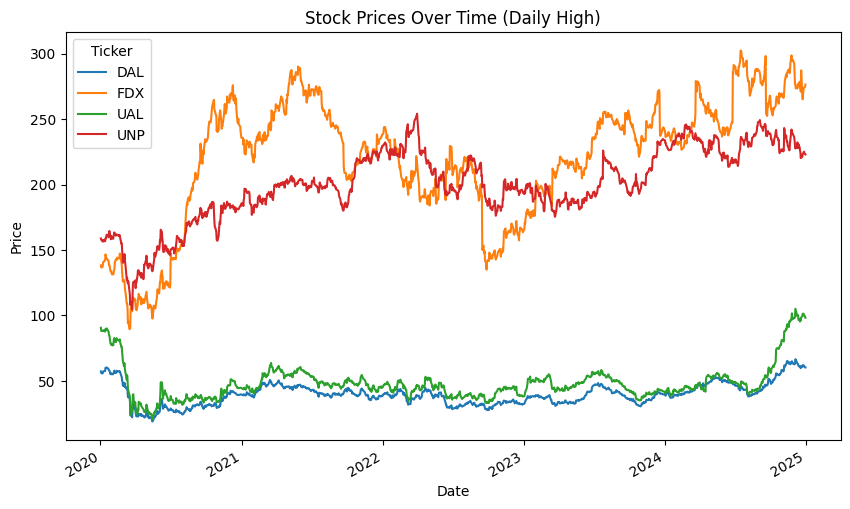

In [13]:
# 1
import matplotlib.pyplot as plt

df.plot(figsize=(10,6))
plt.title("Stock Prices Over Time (Daily High)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [14]:
# 2
volatility = returns.std()
volatility

,0
Ticker,
DAL,0.029321
FDX,0.021801
UAL,0.037255
UNP,0.015060


In [15]:
# 3
correlation_matrix = returns.corr()
correlation_matrix

Ticker,DAL,FDX,UAL,UNP
Ticker,,,,
DAL,1.000000,0.343104,0.904329,0.473448
FDX,0.343104,1.000000,0.343884,0.455522
UAL,0.904329,0.343884,1.000000,0.440876
UNP,0.473448,0.455522,0.440876,1.000000


## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:

This analysis examines the transportation industry and uses Delta (DAL), United (UAL), FedEx (FDX), and Union Pacific (UNP). These companies highlight key segments of transportation; passenger airlines, global logistics, and freight rail. By using five years of data, the goal is to understand price trends, volatility, and how each company operates with one another.

Overall, the stock price shows differences in stability across the industry. The airline stock show larger changes over time, showing sensitivity to economic conditions and demands. FedEx showed moderate variability, while Union Pacific was the most stable. From the returns data, volatility is highest for the airlines and lower for rail, confirming that transportation segments do not have the same level of risk. The correlation matrix shows that most of these stocks move in similar directions, especially during broader market shifts.

I would recommend careful investment in the transportation industry rather than aggressive expansion. The industry shows growth potential but also risk. Overall, this industry may be better suited for diversified portfolios rather than concentrated investment.

To strengthen this recommendation, additional data should be included such as earnings reports, fuel prices, and interest rates. Future analysis could also use forecasting models to predict price trends to measure exposure better. Updating this analysis situationally would provide more accurate and timely investment guidance.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [1]:
!jupyter nbconvert --to html "assignment_14_api_MonbergTobin.ipynb"

[NbConvertApp] Converting notebook assignment_14_api_MonbergTobin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 451546 bytes to assignment_14_api_MonbergTobin.html
